<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/Assignments/Final_Project_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")

Changed directory to: /content/MSSP6070/MSSP6070/MSSP6070/MSSP6070


In [30]:
import pandas as pd

# Construct the full path to the Population.csv file from Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/Population.csv'

# Check if the file exists before attempting to read it
import os
if os.path.exists(file_path):
    population_df = pd.read_csv(file_path)
    print("Successfully loaded Population.csv:")
    print(population_df.head())
else:
    print(f"Error: The file {file_path} was not found. Please ensure the repository is cloned and the file exists at this path.")

Successfully loaded Population.csv:
         Date Province_Name Regency_City_Name  Population
0  2010-01-01     West Java             Bogor      481388
1  2010-01-01     West Java          Sukabumi      235842
2  2010-01-01     West Java           Cianjur      218679
3  2010-01-01     West Java           Bandung      320512
4  2010-01-01     West Java             Garut      242233


In [31]:
# Clean and Preparation
df = population_df.copy()

# Ensure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Sort by region and year
df = df.sort_values(["Regency_City_Name", "Date"])
df.head()


,Date,Province_Name,Regency_City_Name,Population
3,2010-01-01,West Java,Bandung,320512
20,2010-01-01,West Java,Bandung,241209
30,2011-01-01,West Java,Bandung,327283
47,2011-01-01,West Java,Bandung,242918
57,2012-01-01,West Java,Bandung,333968


In [55]:
# Growth Rate
df["Growth_Rate"] = df.groupby("Regency_City_Name")["Population"].pct_change() * 100

df[["Regency_City_Name", "Date", "Population", "Growth_Rate"]].head(10)


,Regency_City_Name,Date,Population,Growth_Rate
3,Bandung,2010-01-01,320512,NaN
20,Bandung,2010-01-01,241209,-24.742599
30,Bandung,2011-01-01,327283,35.684406
47,Bandung,2011-01-01,242918,-25.777385
57,Bandung,2012-01-01,333968,37.481784
74,Bandung,2012-01-01,244462,-26.800771
84,Bandung,2013-01-01,340548,39.305086
101,Bandung,2013-01-01,24585,-92.780753
111,Bandung,2014-01-01,347039,1311.588367
128,Bandung,2014-01-01,24708,-92.880339


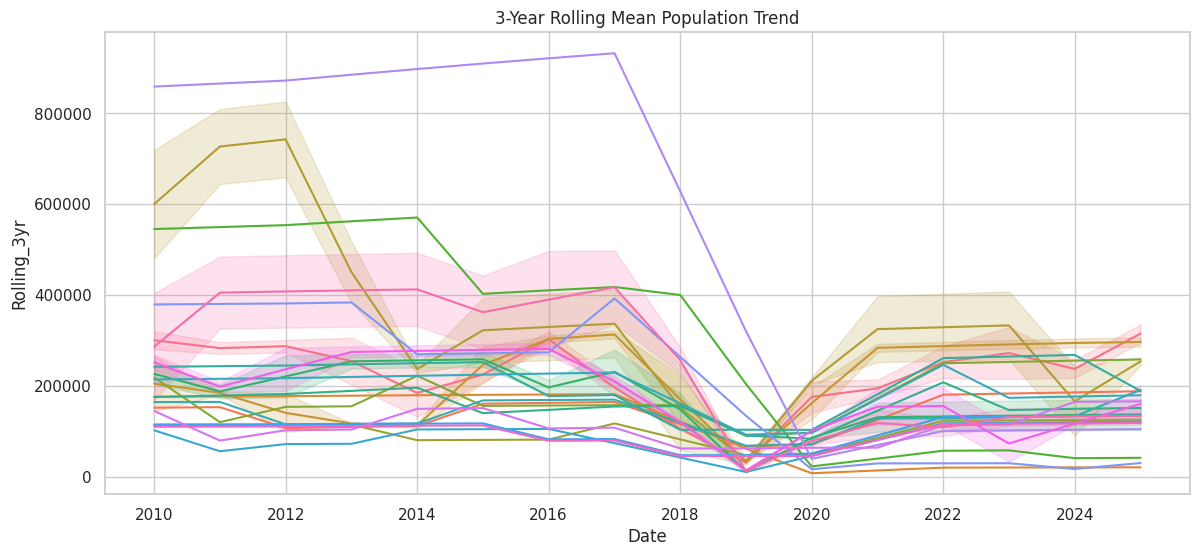

In [56]:
# Rolling Mean
df["Rolling_3yr"] = (
    df.groupby("Regency_City_Name")["Population"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(14,6))
sns.lineplot(data=df, x="Date", y="Rolling_3yr", hue="Regency_City_Name", legend=False)
plt.title("3-Year Rolling Mean Population Trend")
plt.show()


In [57]:
# Z-score
from scipy.stats import zscore

df["Zscore"] = zscore(df["Population"])

z_outliers = df[df["Zscore"].abs() > 3]
print("Z-score outliers:", len(z_outliers))
z_outliers.head()


Z-score outliers: 11


,Date,Province_Name,Regency_City_Name,Population,Growth_Rate,Rolling_3yr,Zscore
18,2010-01-01,West Java,Bogor,958077,99.023864,719732.500000,4.042424
45,2011-01-01,West Java,Bogor,976791,97.580986,809747.666667,4.141802
72,2012-01-01,West Java,Bogor,995081,96.147736,826394.666667,4.238928
13,2010-01-01,West Java,Purwakarta,859186,NaN,859186.000000,3.517279
40,2011-01-01,West Java,Purwakarta,872599,1.561129,865892.500000,3.588507


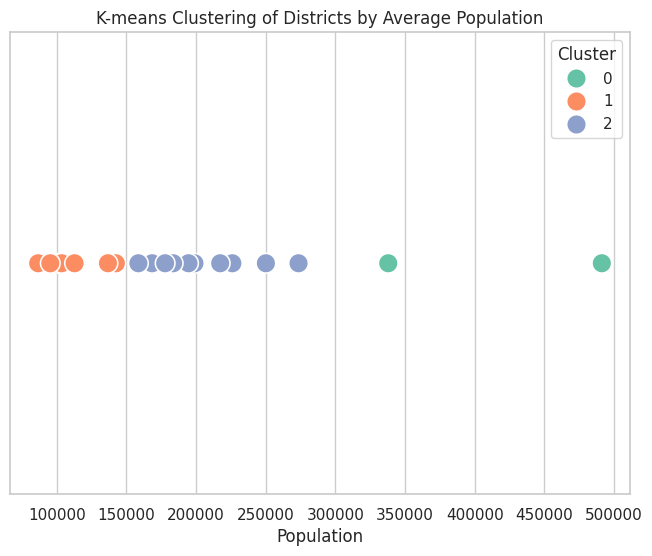

In [59]:
# K-means analysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_avg = df.groupby("Regency_City_Name")["Population"].mean().reset_index()

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(df_avg[["Population"]])

# k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df_avg["Cluster"] = kmeans.fit_predict(X)

df_avg.sort_values("Cluster").head(10)

#  Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_avg,
    x="Population",
    y=[0]*len(df_avg),
    hue="Cluster",
    palette="Set2",
    s=200
)
plt.title("K-means Clustering of Districts by Average Population")
plt.yticks([])
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/tmp/ipython-input-3218241660.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dat

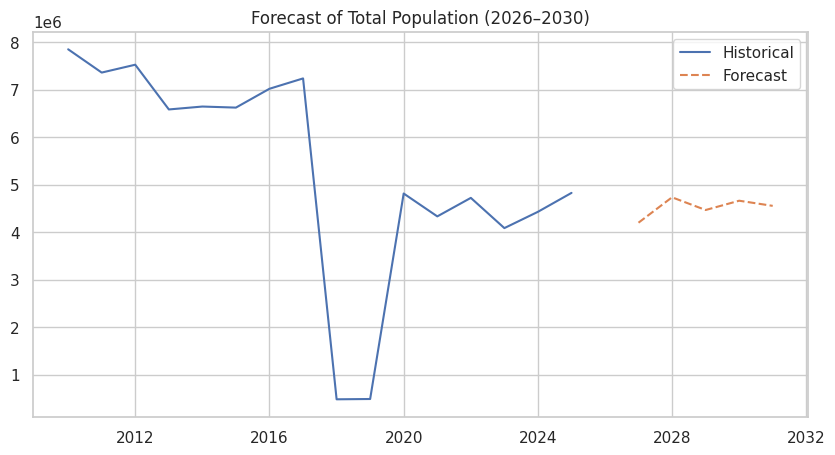

In [60]:
# Total population in the province for ARIMA Prediction
from statsmodels.tsa.arima.model import ARIMA

total_pop = df.groupby("Date")["Population"].sum()

model = ARIMA(total_pop, order=(2,1,2))
fit = model.fit()

forecast = fit.forecast(steps=5)
forecast

# Visualization
future_dates = pd.date_range(
    start=total_pop.index.max(),
    periods=6,
    freq="Y"
)[1:]

plt.figure(figsize=(10,5))
plt.plot(total_pop.index, total_pop.values, label="Historical")
plt.plot(future_dates, forecast, label="Forecast", linestyle="--")
plt.legend()
plt.title("Forecast of Total Population (2026–2030)")
plt.show()


In [45]:
# Gini系数
import numpy as np

def gini(array):
    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    gini_index = (n + 1 - 2*np.sum(cumulative)/cumulative[-1]) / n
    return gini_index

gini_value = gini(df["Population"].values)
print("Gini coefficient:", round(gini_value, 3))


Gini coefficient: 0.479


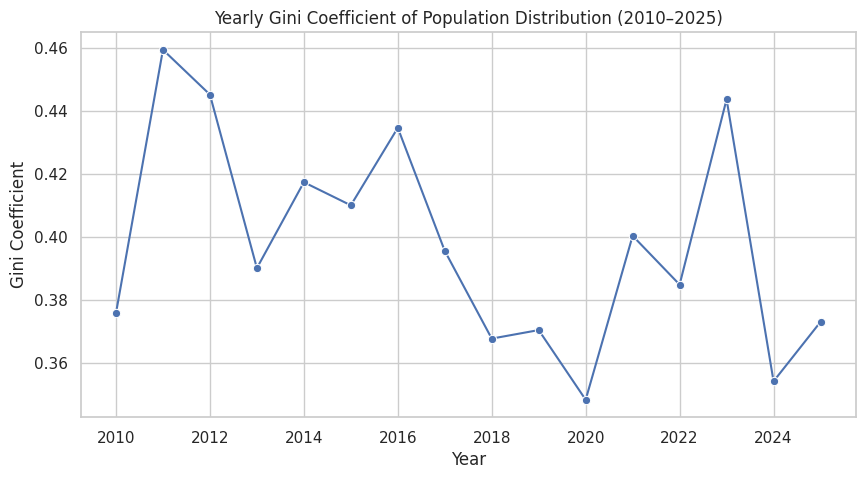

In [47]:
# Evert year's Gini
population_df["Date"] = pd.to_datetime(population_df["Date"], errors="coerce")

gini_by_year = (
    population_df
    .groupby(population_df["Date"].dt.year)["Population"]
    .apply(lambda x: gini(x.values))
)
gini_by_year


plt.figure(figsize=(10,5))
sns.lineplot(x=gini_by_year.index, y=gini_by_year.values, marker="o")
plt.title("Yearly Gini Coefficient of Population Distribution (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Gini Coefficient")
plt.grid(True)
plt.show()


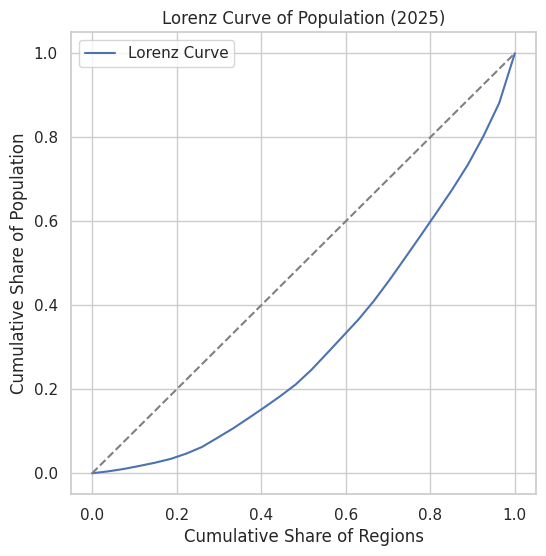

In [48]:
# Lorenz Curve Visualization
def lorenz_curve(arr):
    arr = np.sort(arr)
    cum = np.cumsum(arr)
    lorenz = np.insert(cum / cum[-1], 0, 0)
    return lorenz

df_2025 = population_df[population_df["Date"].dt.year == 2025]
lorenz = lorenz_curve(df_2025["Population"])

plt.figure(figsize=(6,6))
plt.plot(np.linspace(0,1,len(lorenz)), lorenz, label="Lorenz Curve")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("Lorenz Curve of Population (2025)")
plt.xlabel("Cumulative Share of Regions")
plt.ylabel("Cumulative Share of Population")
plt.grid(True)
plt.legend()
plt.show()


In [49]:
# Theil Index
def theil_index(arr):
    arr = np.array(arr)
    mean = arr.mean()
    return np.sum((arr / mean) * np.log(arr / mean)) / len(arr)

theil_2025 = theil_index(df_2025["Population"])
print("Theil Index (2025):", round(theil_2025, 3))


Theil Index (2025): 0.234


In [61]:
# Quantile Bins
df_2025["Quantile"] = pd.qcut(df_2025["Population"], q=4, labels=["Q1","Q2","Q3","Q4"])
df_2025.groupby("Quantile")["Population"].describe()


/tmp/ipython-input-4136236665.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["Quantile"] = pd.qcut(df_2025["Population"], q=4, labels=["Q1","Q2","Q3","Q4"])
/tmp/ipython-input-4136236665.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2025.groupby("Quantile")["Population"].describe()


,count,mean,std,min,25%,50%,75%,max
Quantile,,,,,,,,
Q1,7.0,42961.285714,19216.349148,21196.0,31120.50,37068.0,52143.50,75937.0
Q2,7.0,126762.571429,20747.596109,106297.0,113965.50,122549.0,131504.50,167552.0
Q3,6.0,215078.333333,27627.048461,190782.0,193284.25,205088.5,235234.75,254878.0
Q4,7.0,335711.428571,113229.322376,258125.0,262929.50,285211.0,354311.50,572162.0


In [62]:
# Population Share of Top-k Cities
df_sorted = df_2025.sort_values("Population", ascending=False)
top_3_share = df_sorted.head(3)["Population"].sum() / df_sorted["Population"].sum()
top_5_share = df_sorted.head(5)["Population"].sum() / df_sorted["Population"].sum()

print("Top 3 cities share:", round(top_3_share,3))
print("Top 5 cities share:", round(top_5_share,3))


Top 3 cities share: 0.265
Top 5 cities share: 0.379
